In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk 
from nltk.corpus import stopwords
nltk.download('stopwords')
stop = set(stopwords.words('english'))

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>


In [2]:
df = pd.read_csv(r"/Users/admin/Desktop/Open ME/Udemy Work/Toxic Comment Classification/data/train.csv")
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
# Check if there are any duplicate rows
print("The shape of the dataset before removing duplicates: ", df.shape)
df = df.drop_duplicates()
print("The shape of the dataset after removing duplicates: ", df.shape)

The shape of the dataset before removing duplicates:  (159571, 8)
The shape of the dataset after removing duplicates:  (159571, 8)


In [4]:
# Check for missing values
df.isna().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [5]:
# Analysing the distribution of the labels
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
df['label_sum'] = df[label_cols].sum(axis=1)
df['label_sum'].value_counts()

label_sum
0    143346
1      6360
3      4209
2      3480
4      1760
5       385
6        31
Name: count, dtype: int64

In [6]:
# Print the number of comments in each category

for i in label_cols:
    print("The number of comments in the category ", i, " is: ", df[i].sum())

The number of comments in the category  toxic  is:  15294
The number of comments in the category  severe_toxic  is:  1595
The number of comments in the category  obscene  is:  8449
The number of comments in the category  threat  is:  478
The number of comments in the category  insult  is:  7877
The number of comments in the category  identity_hate  is:  1405


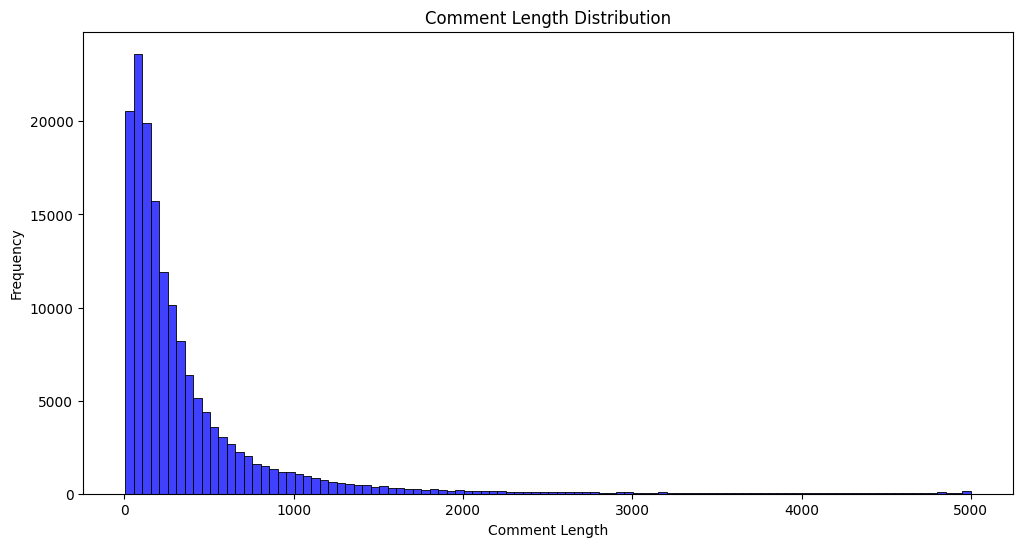

In [7]:
# Visualise comment length distribution
df['comment_length'] = df['comment_text'].apply(len)
plt.figure(figsize=(12, 6))
sns.histplot(df['comment_length'], bins=100, color='blue')
plt.title('Comment Length Distribution')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [8]:
df['comment_text'][1]

"D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)"

In [9]:
# "Hey man, I'm really not trying to edit war. 
# It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. 
# He seems to care more about the formatting than the actual info."

'Hey man I m really not trying to edit war It s just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page He seems to care more about the formatting than the actual info '


'Hey man I m really not trying to edit war It s just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page He seems to care more about the formatting than the actual info '

In [10]:
# Remove URL from the comment_text items
df['comment_text'] = df['comment_text'].str.replace('http\S+|www.\S+', '', case=False)

# Remove all numbers from the comment_text items
df['comment_text'] = df['comment_text'].str.replace('\d+', '', regex=True)

# Remove all stopwords from the comment_text items
df['comment_text'] = df['comment_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

# Remove special characters from the comment_text items
df['comment_text'] = df['comment_text'].str.replace('[^A-Za-z0-9]+', ' ', regex=True)

# Remove any HTML tags from the comment_text items without using bs4
df['comment_text'] = df['comment_text'].str.replace('<.*?>', '', regex=True)




In [11]:
df['comment_text'][2]  

'Hey man I m really trying edit war It s guy constantly removing relevant information talking edits instead talk page He seems care formatting actual info '

In [12]:
# Convert all items in the comment_text column to lowercase
df['comment_text'] = df['comment_text'].str.lower()

In [13]:
# Tokenising the comment_text items

from nltk.tokenize import word_tokenize
df['comment_text'] = df['comment_text'].apply(word_tokenize)

df['comment_text'][2]

['hey',
 'man',
 'i',
 'm',
 'really',
 'trying',
 'edit',
 'war',
 'it',
 's',
 'guy',
 'constantly',
 'removing',
 'relevant',
 'information',
 'talking',
 'edits',
 'instead',
 'talk',
 'page',
 'he',
 'seems',
 'care',
 'formatting',
 'actual',
 'info']

In [14]:
# In each item in comment_text, remove any empty strings, strings containing only one character, and strings containing only digits
df['comment_text'] = df['comment_text'].apply(lambda x: [item for item in x if len(item) > 1 and not item.isdigit()])
df['comment_text'][2]

['hey',
 'man',
 'really',
 'trying',
 'edit',
 'war',
 'it',
 'guy',
 'constantly',
 'removing',
 'relevant',
 'information',
 'talking',
 'edits',
 'instead',
 'talk',
 'page',
 'he',
 'seems',
 'care',
 'formatting',
 'actual',
 'info']

In [15]:
# Perform Lemmatization on the comment_text items
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
df['comment_text'] = df['comment_text'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

df['comment_text'][2]

['hey',
 'man',
 'really',
 'trying',
 'edit',
 'war',
 'it',
 'guy',
 'constantly',
 'removing',
 'relevant',
 'information',
 'talking',
 'edits',
 'instead',
 'talk',
 'page',
 'he',
 'seems',
 'care',
 'formatting',
 'actual',
 'info']

In [16]:
# Remove all stopwords from the comment_text items
df['comment_text'] = df['comment_text'].apply(lambda x: ' '.join([word for word in x if word not in (stop)]))

df['comment_text'][2]

'hey man really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info'

In [17]:
# Perform tokenization on the comment_text items
# df['comment_text'] = df['comment_text'].apply(word_tokenize)

# df['comment_text'][2]

In [18]:
# Find the item with the largest length in comment_text
max_length = max(df['comment_text'].apply(len))

print("The item with the largest length in comment_text is: ", df[df['comment_text'].apply(len) == max_length]['comment_text'].values[0])
print("The length of the item with the largest length in comment_text is: ", max_length)

The item with the largest length in comment_text is:  securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland securityfuck homeland 

In [19]:
# Convert the list into a set and then back into a list to remove duplicates
# df['comment_text'] = df['comment_text'].apply(lambda x: list(set(x)))


In [20]:
# Find the item with the largest length in comment_text
# max_length = max(df['comment_text'].apply(len))

# print("The item with the largest length in comment_text is: ", df[df['comment_text'].apply(len) == max_length]['comment_text'].values[0])
# print("The length of the item with the largest length in comment_text is: ", max_length)

In [21]:
# Perform TF-IDF Vectorization on the comment_text items
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = tfidf = TfidfVectorizer(
    max_features=10000,  # Limit vocabulary size
    min_df=5,            # Appear in at least 5 documents
    max_df=0.7           # Appear in no more than 70% of documents
)
tfidf_matrix = tfidf.fit_transform(df['comment_text'])
tfidf_matrix = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
tfidf_matrix.head()

,aa,aaron,ab,abandon,abandoned,abbey,abbreviation,abc,abd,abdul,...,zeus,zinc,zionism,zionist,zoe,zombie,zone,zoo,zuck,zuckerberg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,label_sum,comment_length
0,0000997932d777bf,explanation edits made username hardcore metal...,0,0,0,0,0,0,0,264
1,000103f0d9cfb60f,aww match background colour seemingly stuck th...,0,0,0,0,0,0,0,112
2,000113f07ec002fd,hey man really trying edit war guy constantly ...,0,0,0,0,0,0,0,233
3,0001b41b1c6bb37e,make real suggestion improvement wondered sect...,0,0,0,0,0,0,0,622
4,0001d958c54c6e35,sir hero chance remember page,0,0,0,0,0,0,0,67


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

X = tfidf_matrix
# There are multiple labels, so we need to train a model for each label
y = df['toxic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_toxic = LogisticRegression(max_iter=1000)
model_toxic.fit(X_train, y_train)
y_pred = model_toxic.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy of the model is: ", accuracy)
f1 = f1_score(y_test, y_pred)
print("The F1 score of the model is: ", f1)



The accuracy of the model is:  0.9576688077706408
The F1 score of the model is:  0.737312852420766


In [24]:
# Train a Logistic Regression model for severe_toxic using the same training and testing data 
y = df['severe_toxic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_severe_toxic = LogisticRegression(max_iter=1000)
model_severe_toxic.fit(X_train, y_train)
y_pred = model_severe_toxic.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy of the model is: ", accuracy)
f1 = f1_score(y_test, y_pred)
print("The F1 score of the model is: ", f1)


The accuracy of the model is:  0.9905686981043397
The F1 score of the model is:  0.36363636363636365


In [25]:
# Train a Logistic Regression model for obscene using the same training and testing data
y = df['obscene']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_obscene = LogisticRegression(max_iter=1000)
model_obscene.fit(X_train, y_train)
y_pred = model_obscene.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy of the model is: ", accuracy)
f1 = f1_score(y_test, y_pred)
print("The F1 score of the model is: ", f1)


The accuracy of the model is:  0.9765314115619614
The F1 score of the model is:  0.7387513079874434


In [26]:
# Train a Logistic Regression model for threat using the same training and testing data
y = df['threat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_threat = LogisticRegression(max_iter=1000)
model_threat.fit(X_train, y_train)
y_pred = model_threat.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy of the model is: ", accuracy)
f1 = f1_score(y_test, y_pred)
print("The F1 score of the model is: ", f1)

The accuracy of the model is:  0.9978066739777534
The F1 score of the model is:  0.18604651162790697


In [27]:
# Train a Logistic Regression model for insult using the same training and testing data
y = df['insult']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_insult = LogisticRegression(max_iter=1000)
model_insult.fit(X_train, y_train)
y_pred = model_insult.predict(X_test)  
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy of the model is: ", accuracy)
f1 = f1_score(y_test, y_pred)
print("The F1 score of the model is: ", f1)


The accuracy of the model is:  0.9695441015196616
The F1 score of the model is:  0.6312594840667678


In [28]:
# Train a Logistic Regression model for identity_hate using the same training and testing data
y = df['identity_hate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_identity_hate = LogisticRegression(max_iter=1000)
model_identity_hate.fit(X_train, y_train)
y_pred = model_identity_hate.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy of the model is: ", accuracy)
f1 = f1_score(y_test, y_pred)
print("The F1 score of the model is: ", f1)


The accuracy of the model is:  0.9918533604887984
The F1 score of the model is:  0.2777777777777778


In [29]:
# Now I want to use all these models to predict the labels of the test data
df_test = pd.read_csv(r"/Users/admin/Desktop/Open ME/Udemy Work/Toxic Comment Classification/data/test.csv")
df_test.head()


,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [30]:
# Remove URL from the comment_text items
df_test['comment_text'] = df_test['comment_text'].str.replace('http\S+|www.\S+', '', case=False)

# Remove all numbers from the comment_text items
df_test['comment_text'] = df_test['comment_text'].str.replace('\d+', '', regex=True)

# Remove all stopwords from the comment_text items
df_test['comment_text'] = df_test['comment_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

# Remove special characters from the comment_text items
df_test['comment_text'] = df_test['comment_text'].str.replace('[^A-Za-z0-9]+', ' ', regex=True)

# Remove any HTML tags from the comment_text items without using bs4
df_test['comment_text'] = df_test['comment_text'].str.replace('<.*?>', '', regex=True)

# Convert all items in the comment_text column to lowercase
df_test['comment_text'] = df_test['comment_text'].str.lower()

# Tokenising the comment_text items
df_test['comment_text'] = df_test['comment_text'].apply(word_tokenize)

# In each item in comment_text, remove any empty strings, strings containing only one character, and strings containing only digits
df_test['comment_text'] = df_test['comment_text'].apply(lambda x: [item for item in x if len(item) > 1 and not item.isdigit()])



In [31]:
# Perform Lemmatization on the comment_text items
df_test['comment_text'] = df_test['comment_text'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

# Remove all stopwords from the comment_text items
df_test['comment_text'] = df_test['comment_text'].apply(lambda x: ' '.join([word for word in x if word not in (stop)]))

# Perform TF-IDF Vectorization on the comment_text items
tfidf_matrix_test = tfidf.transform(df_test['comment_text'])
tfidf_matrix_test = pd.DataFrame(tfidf_matrix_test.toarray(), columns=tfidf.get_feature_names_out())
tfidf_matrix_test.head()

,aa,aaron,ab,abandon,abandoned,abbey,abbreviation,abc,abd,abdul,...,zeus,zinc,zionism,zionist,zoe,zombie,zone,zoo,zuck,zuckerberg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# Predict the labels of the test data using the models trained earlier
df_test['toxic'] = model_toxic.predict(tfidf_matrix_test)
df_test['severe_toxic'] = model_severe_toxic.predict(tfidf_matrix_test)
df_test['obscene'] = model_obscene.predict(tfidf_matrix_test)
df_test['threat'] = model_threat.predict(tfidf_matrix_test)
df_test['insult'] = model_insult.predict(tfidf_matrix_test)
df_test['identity_hate'] = model_identity_hate.predict(tfidf_matrix_test)


In [33]:
# Read the sample submission file
df_sample = pd.read_csv(r"/Users/admin/Desktop/Open ME/Udemy Work/Toxic Comment Classification/data/sample_submission.csv")
df_sample.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.5,0.5,0.5,0.5,0.5,0.5
1,0000247867823ef7,0.5,0.5,0.5,0.5,0.5,0.5
2,00013b17ad220c46,0.5,0.5,0.5,0.5,0.5,0.5
3,00017563c3f7919a,0.5,0.5,0.5,0.5,0.5,0.5
4,00017695ad8997eb,0.5,0.5,0.5,0.5,0.5,0.5


In [34]:
# Create a dataframe with the prediction following the same format as the sample submission file
df_submission = df_test[['id', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]
df_submission.head()

# Save the dataframe as a CSV file
df_submission.to_csv(r"/Users/admin/Desktop/Open ME/Udemy Work/Toxic Comment Classification/data/submission.csv", index=False)


In [35]:
# Baseline model accuracy is 71.5% 